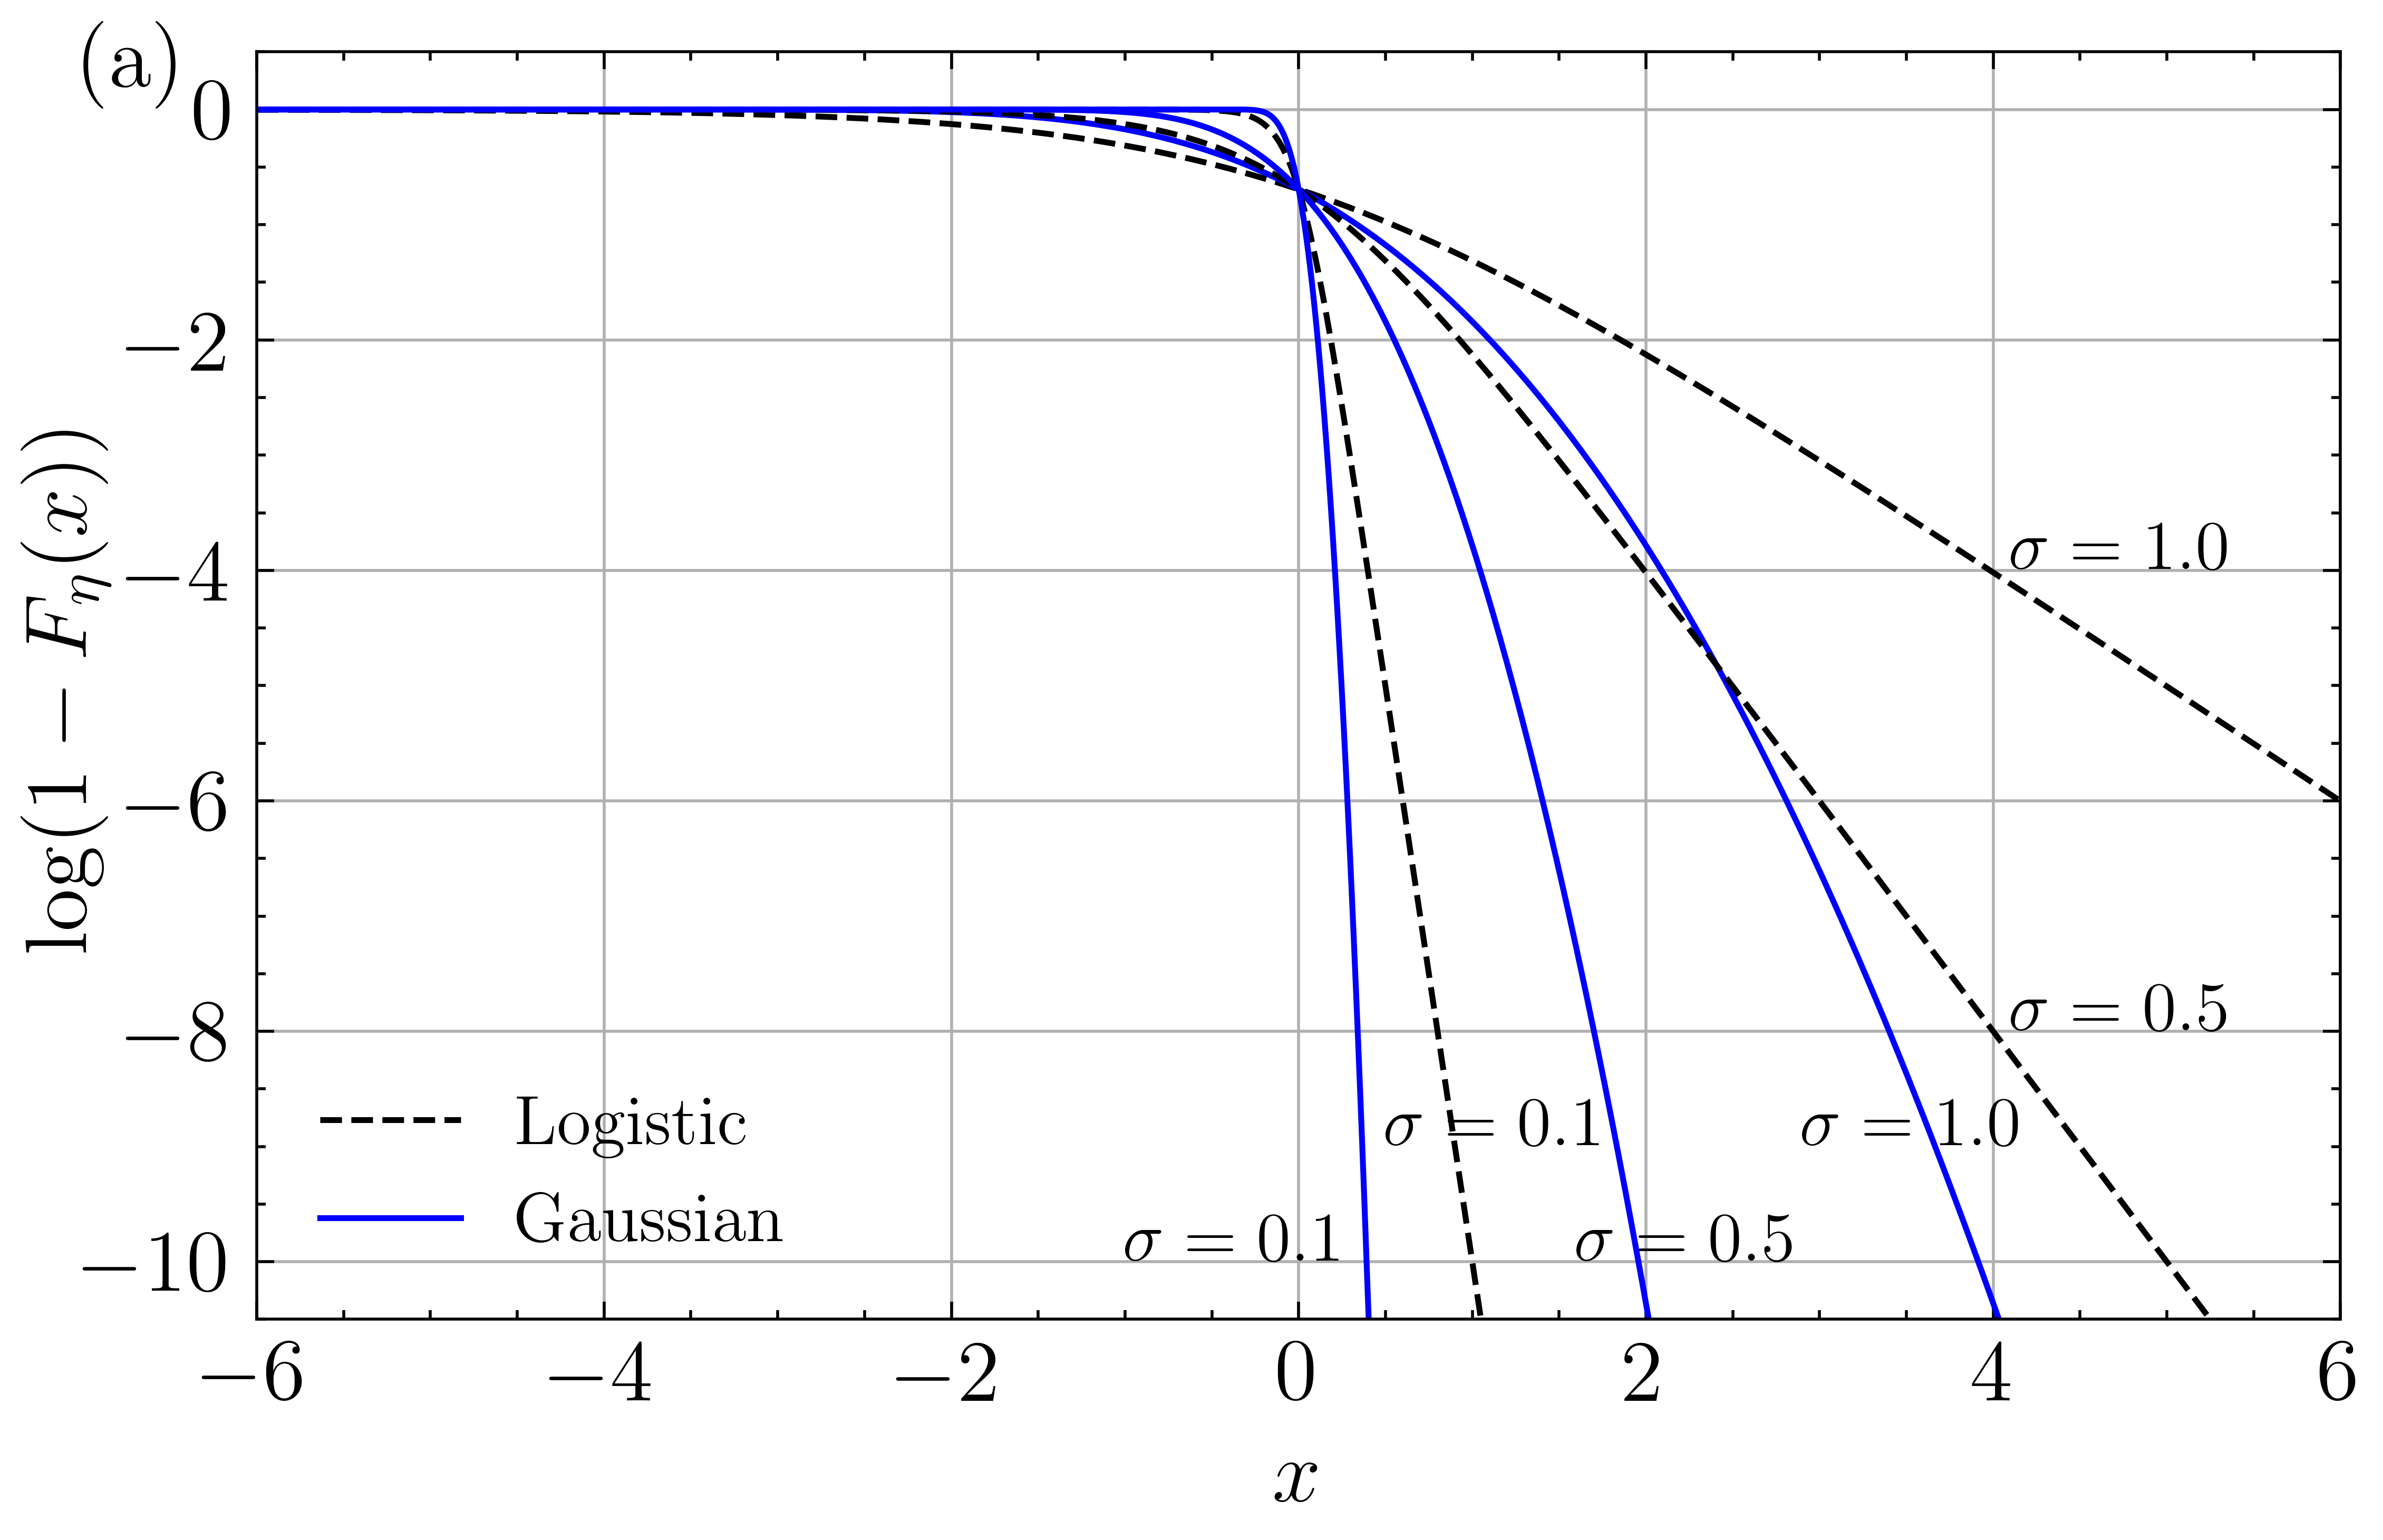

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
from matplotlib.lines import Line2D

# 设置样式与字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 使用 float64 以防止数值震荡
dtype = torch.float64
u = torch.linspace(-6, 6, 1000, dtype=dtype)

# 函数定义
def log1m_logistic_cdf(u, sigma):
    return torch.log1p(-1 / (1 + torch.exp(-u / sigma)))

def log1m_gaussian_cdf(u, sigma):
    cdf = 0.5 + 0.5 * torch.erf(u / (math.sqrt(2) * sigma))
    return torch.log(torch.clamp(1.0 - cdf, min=1e-12))  # 防止 log(0)

# sigma 和颜色设置
sigmas = [1.0, 0.5, 0.1]
colors = ['black', 'gray', 'lightgray']

# 创建图
fig, ax = plt.subplots(figsize=(6.0, 4.0))

for sigma, color in zip(sigmas, colors):
    y_logistic = log1m_logistic_cdf(u, sigma)
    y_gaussian = log1m_gaussian_cdf(u, sigma)

    # Logistic：虚线
    ax.plot(u, y_logistic, linestyle='--', color='black')
    # Gaussian：实线
    ax.plot(u, y_gaussian, linestyle='-', color='blue')

# 手动标注 sigma
ax.text(4.1, -4, r'$\sigma=1.0$', fontsize=12)
ax.text(4.1, -8, r'$\sigma=0.5$', fontsize=12)
ax.text(0.5, -9, r'$\sigma=0.1$', fontsize=12)
ax.text(2.9, -9, r'$\sigma=1.0$', fontsize=12)
ax.text(1.6, -10, r'$\sigma=0.5$', fontsize=12)
ax.text(-1, -10, r'$\sigma=0.1$', fontsize=12)
# 坐标轴标签
ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$\log(1 - F_\eta(x))$', fontsize=15, labelpad=-5)

# y轴范围
ax.set_ylim(-10.5, 0.5)
ax.set_xlim(-6, 6)
ax.grid(True)

# 自定义 legend：线型表示分布类型
custom_lines = [
    Line2D([0], [0], color='black', linestyle='--', lw=1),
    Line2D([0], [0], color='blue', linestyle='-', lw=1)
]
ax.legend(custom_lines, ['Logistic', 'Gaussian'], loc='lower left', fontsize=12)

# 子图标签 (b)
ax.text(-7, 0.2, '(a)', fontsize=15)

# 紧凑布局 & 保存
fig.tight_layout()
fig.savefig('D:/PRE2025/Fig2a.eps', dpi=800, format='eps')  # 自定义路径

plt.show()


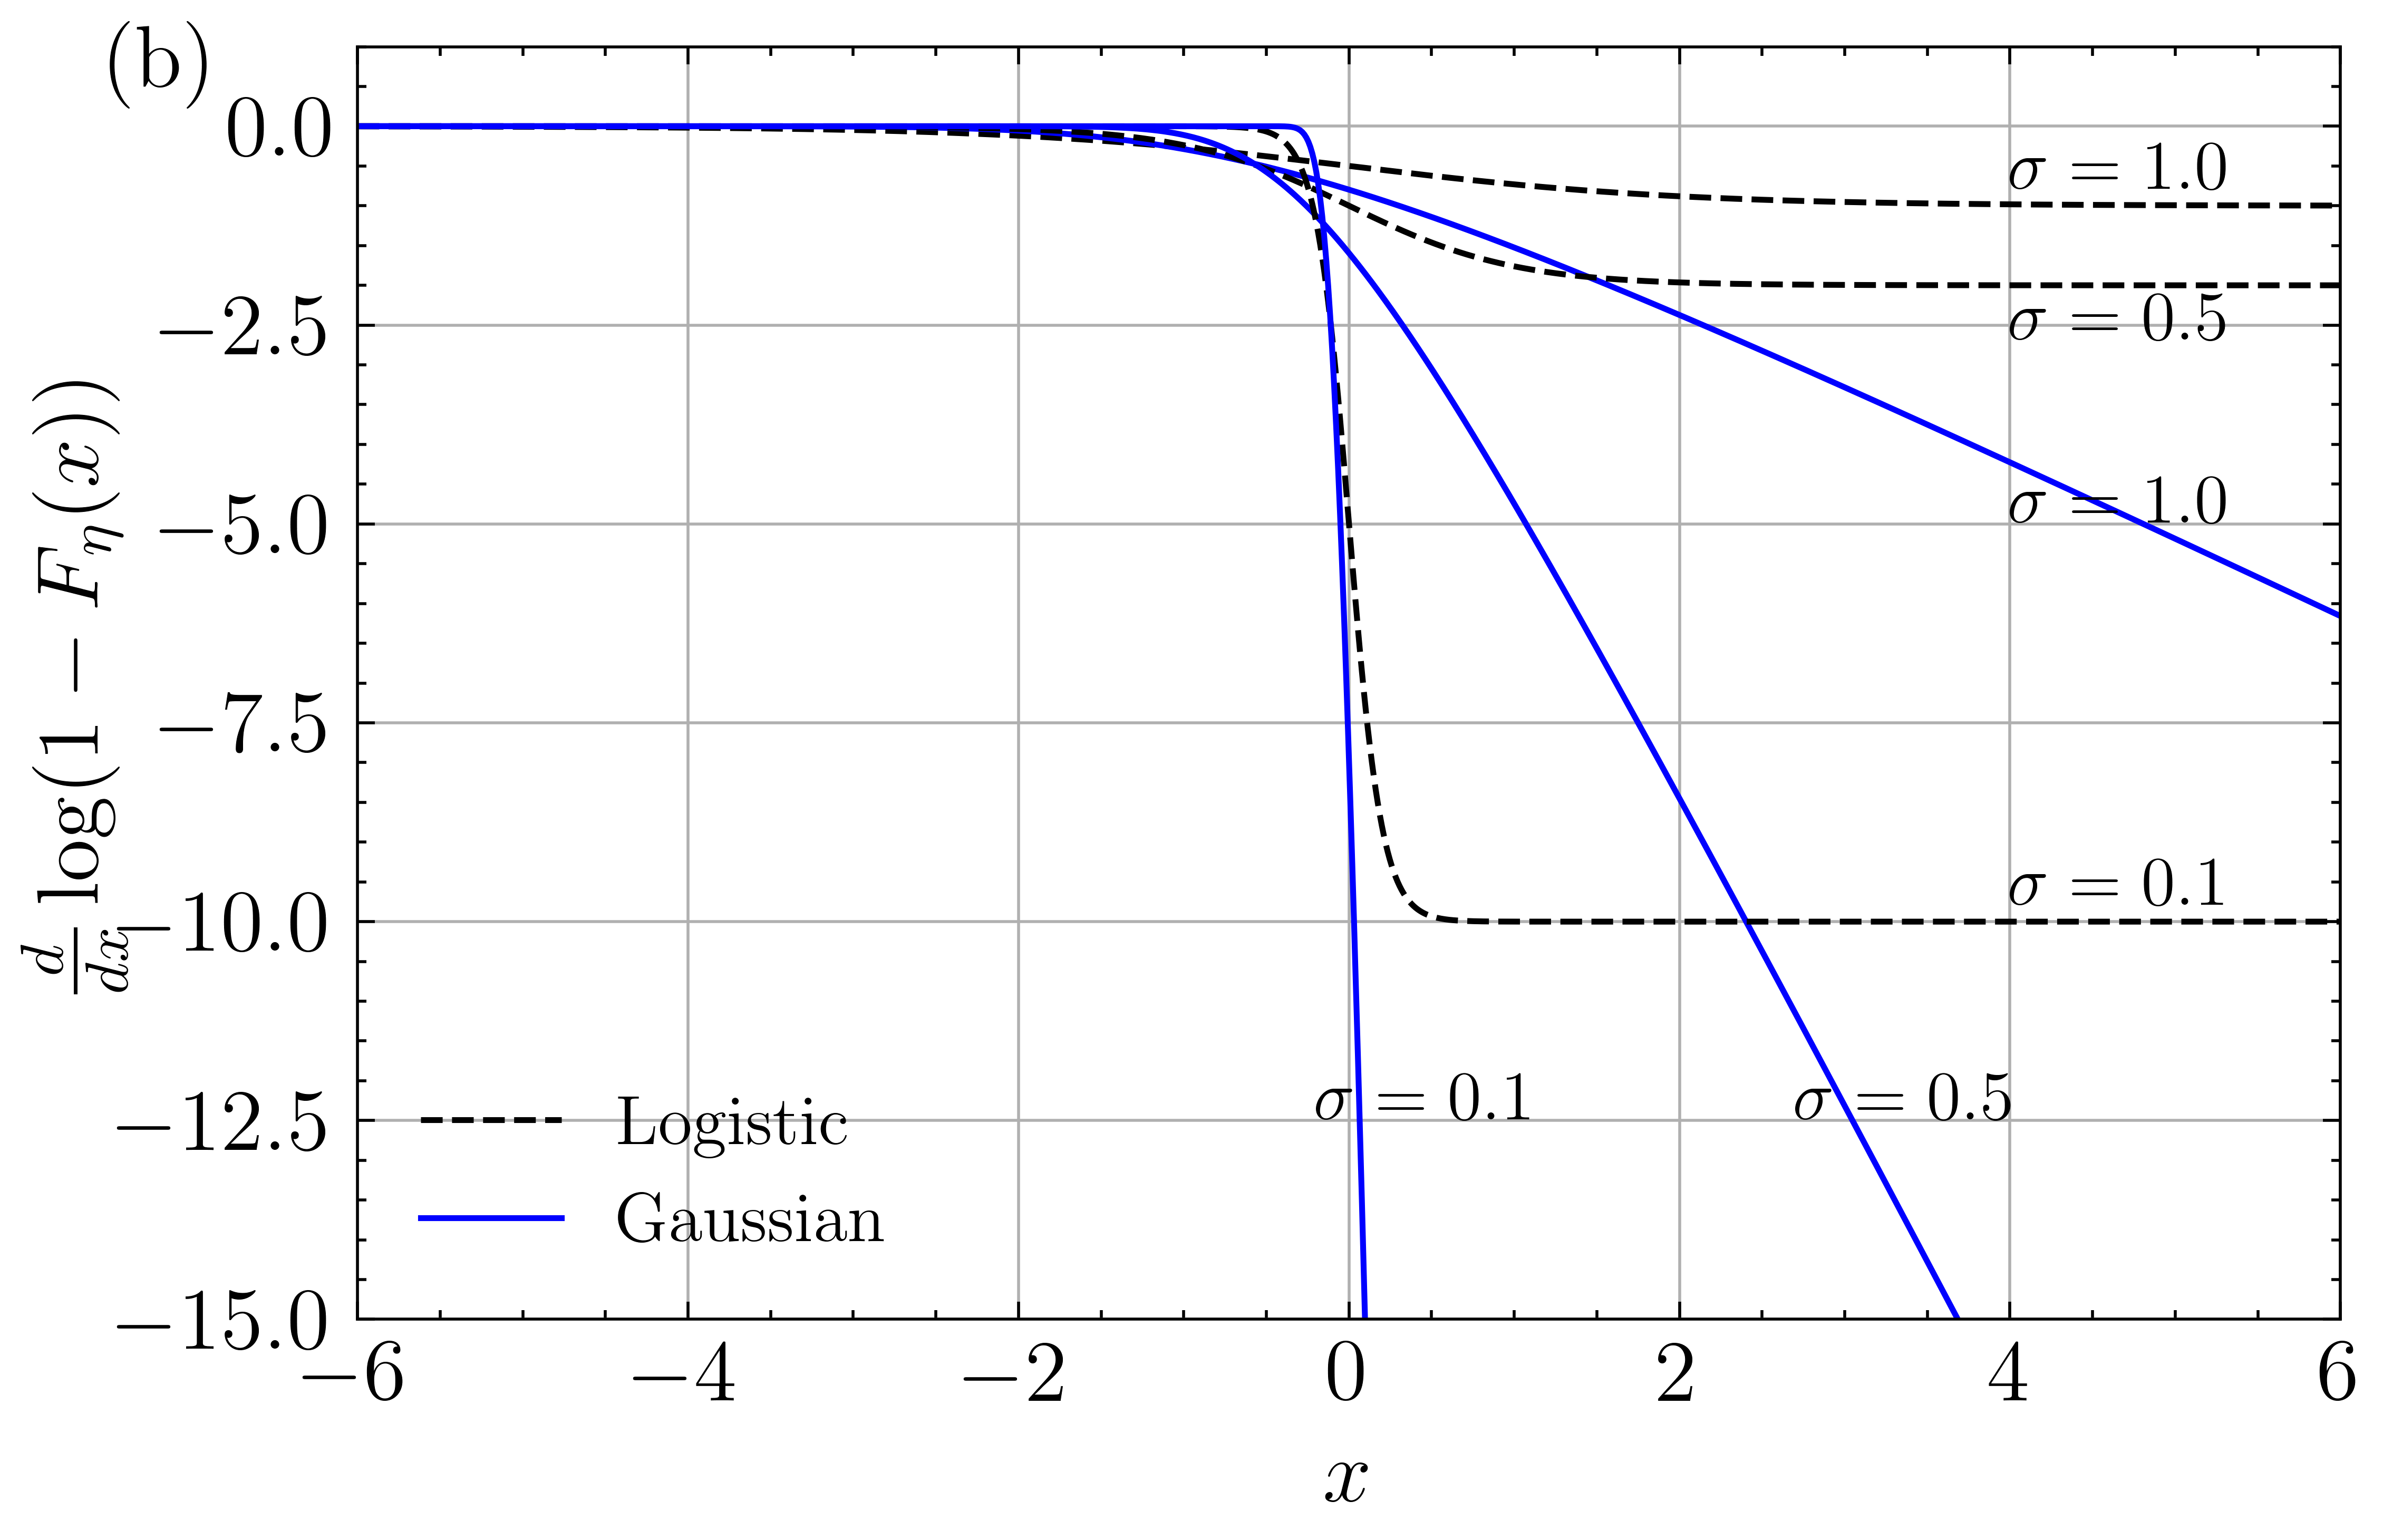

In [45]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
from matplotlib.lines import Line2D

# 设置样式
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 设置 u 轴
u = torch.linspace(-6, 6, 1000, dtype=torch.float64)
u.requires_grad_(True)

sigmas = [1.0, 0.5, 0.1]

# Logistic CDF and log(1 - CDF)
def log_one_minus_logistic_cdf(u, sigma):
    return -torch.nn.functional.softplus(u / sigma)  # log(1 - sigmoid(u/sigma))

# Gaussian log(1 - CDF)
def log_one_minus_gaussian_cdf(u, sigma):
    return torch.special.log_ndtr(-u / sigma)

### --------- 图 (b): gradient of log(1 - F_eta(x)) ----------
fig_b, ax_b = plt.subplots(figsize=(6.0, 4.0))

# 创建图例线条
custom_lines = [Line2D([0], [0], color='black', linestyle='--'),
                Line2D([0], [0], color='blue', linestyle='-')]

for sigma in sigmas:
    # Logistic gradient - 黑色虚线
    u_logistic = u.clone().detach().requires_grad_(True)
    log_logistic = log_one_minus_logistic_cdf(u_logistic, sigma)
    grad_log_logistic = torch.autograd.grad(log_logistic.sum(), u_logistic, create_graph=False)[0]
    ax_b.plot(u_logistic.detach(), grad_log_logistic.detach(),
              linestyle='--', color='black',
              label=f'Logistic σ={sigma}' if sigma == sigmas[0] else "")
    


    
    # Gaussian gradient - 蓝色实线
    u_gaussian = u.clone().detach().requires_grad_(True)
    log_gaussian = log_one_minus_gaussian_cdf(u_gaussian, sigma)
    grad_log_gaussian = torch.autograd.grad(log_gaussian.sum(), u_gaussian, create_graph=False)[0]
    ax_b.plot(u_gaussian.detach(), grad_log_gaussian.detach(),
              linestyle='-', color='blue',
              label=f'Gaussian σ={sigma}' if sigma == sigmas[0] else "")



ax_b.set_xlabel(r'$x$', fontsize=15)
ax_b.set_ylabel(r'$\frac{d}{dx} \log(1 - F_\eta(x))$', fontsize=15, labelpad=-2)
ax_b.set_xlim(-6, 6)
ax_b.set_ylim(-15, 1)
ax_b.grid(True)

ax_b.text(4.0, -0.8, r'$\sigma=1.0$', fontsize=12)
ax_b.text(4.0, -2.7, r'$\sigma=0.5$', fontsize=12)
ax_b.text(4.0, -9.8, r'$\sigma=0.1$', fontsize=12)
ax_b.text(4.0, -5, r'$\sigma=1.0$', fontsize=12)
ax_b.text(2.7, -12.5, r'$\sigma=0.5$', fontsize=12)
ax_b.text(-0.2, -12.5, r'$\sigma=0.1$', fontsize=12)

# 修正图例
ax_b.legend(custom_lines, ['Logistic', 'Gaussian'], loc='lower left', fontsize=12)
ax_b.text(-7.5, 0.5, '(b)', fontsize=15)

fig_b.tight_layout()
fig_b.savefig('D:/PRE2025/Fig2b.eps', dpi=800, format='eps')
plt.show()

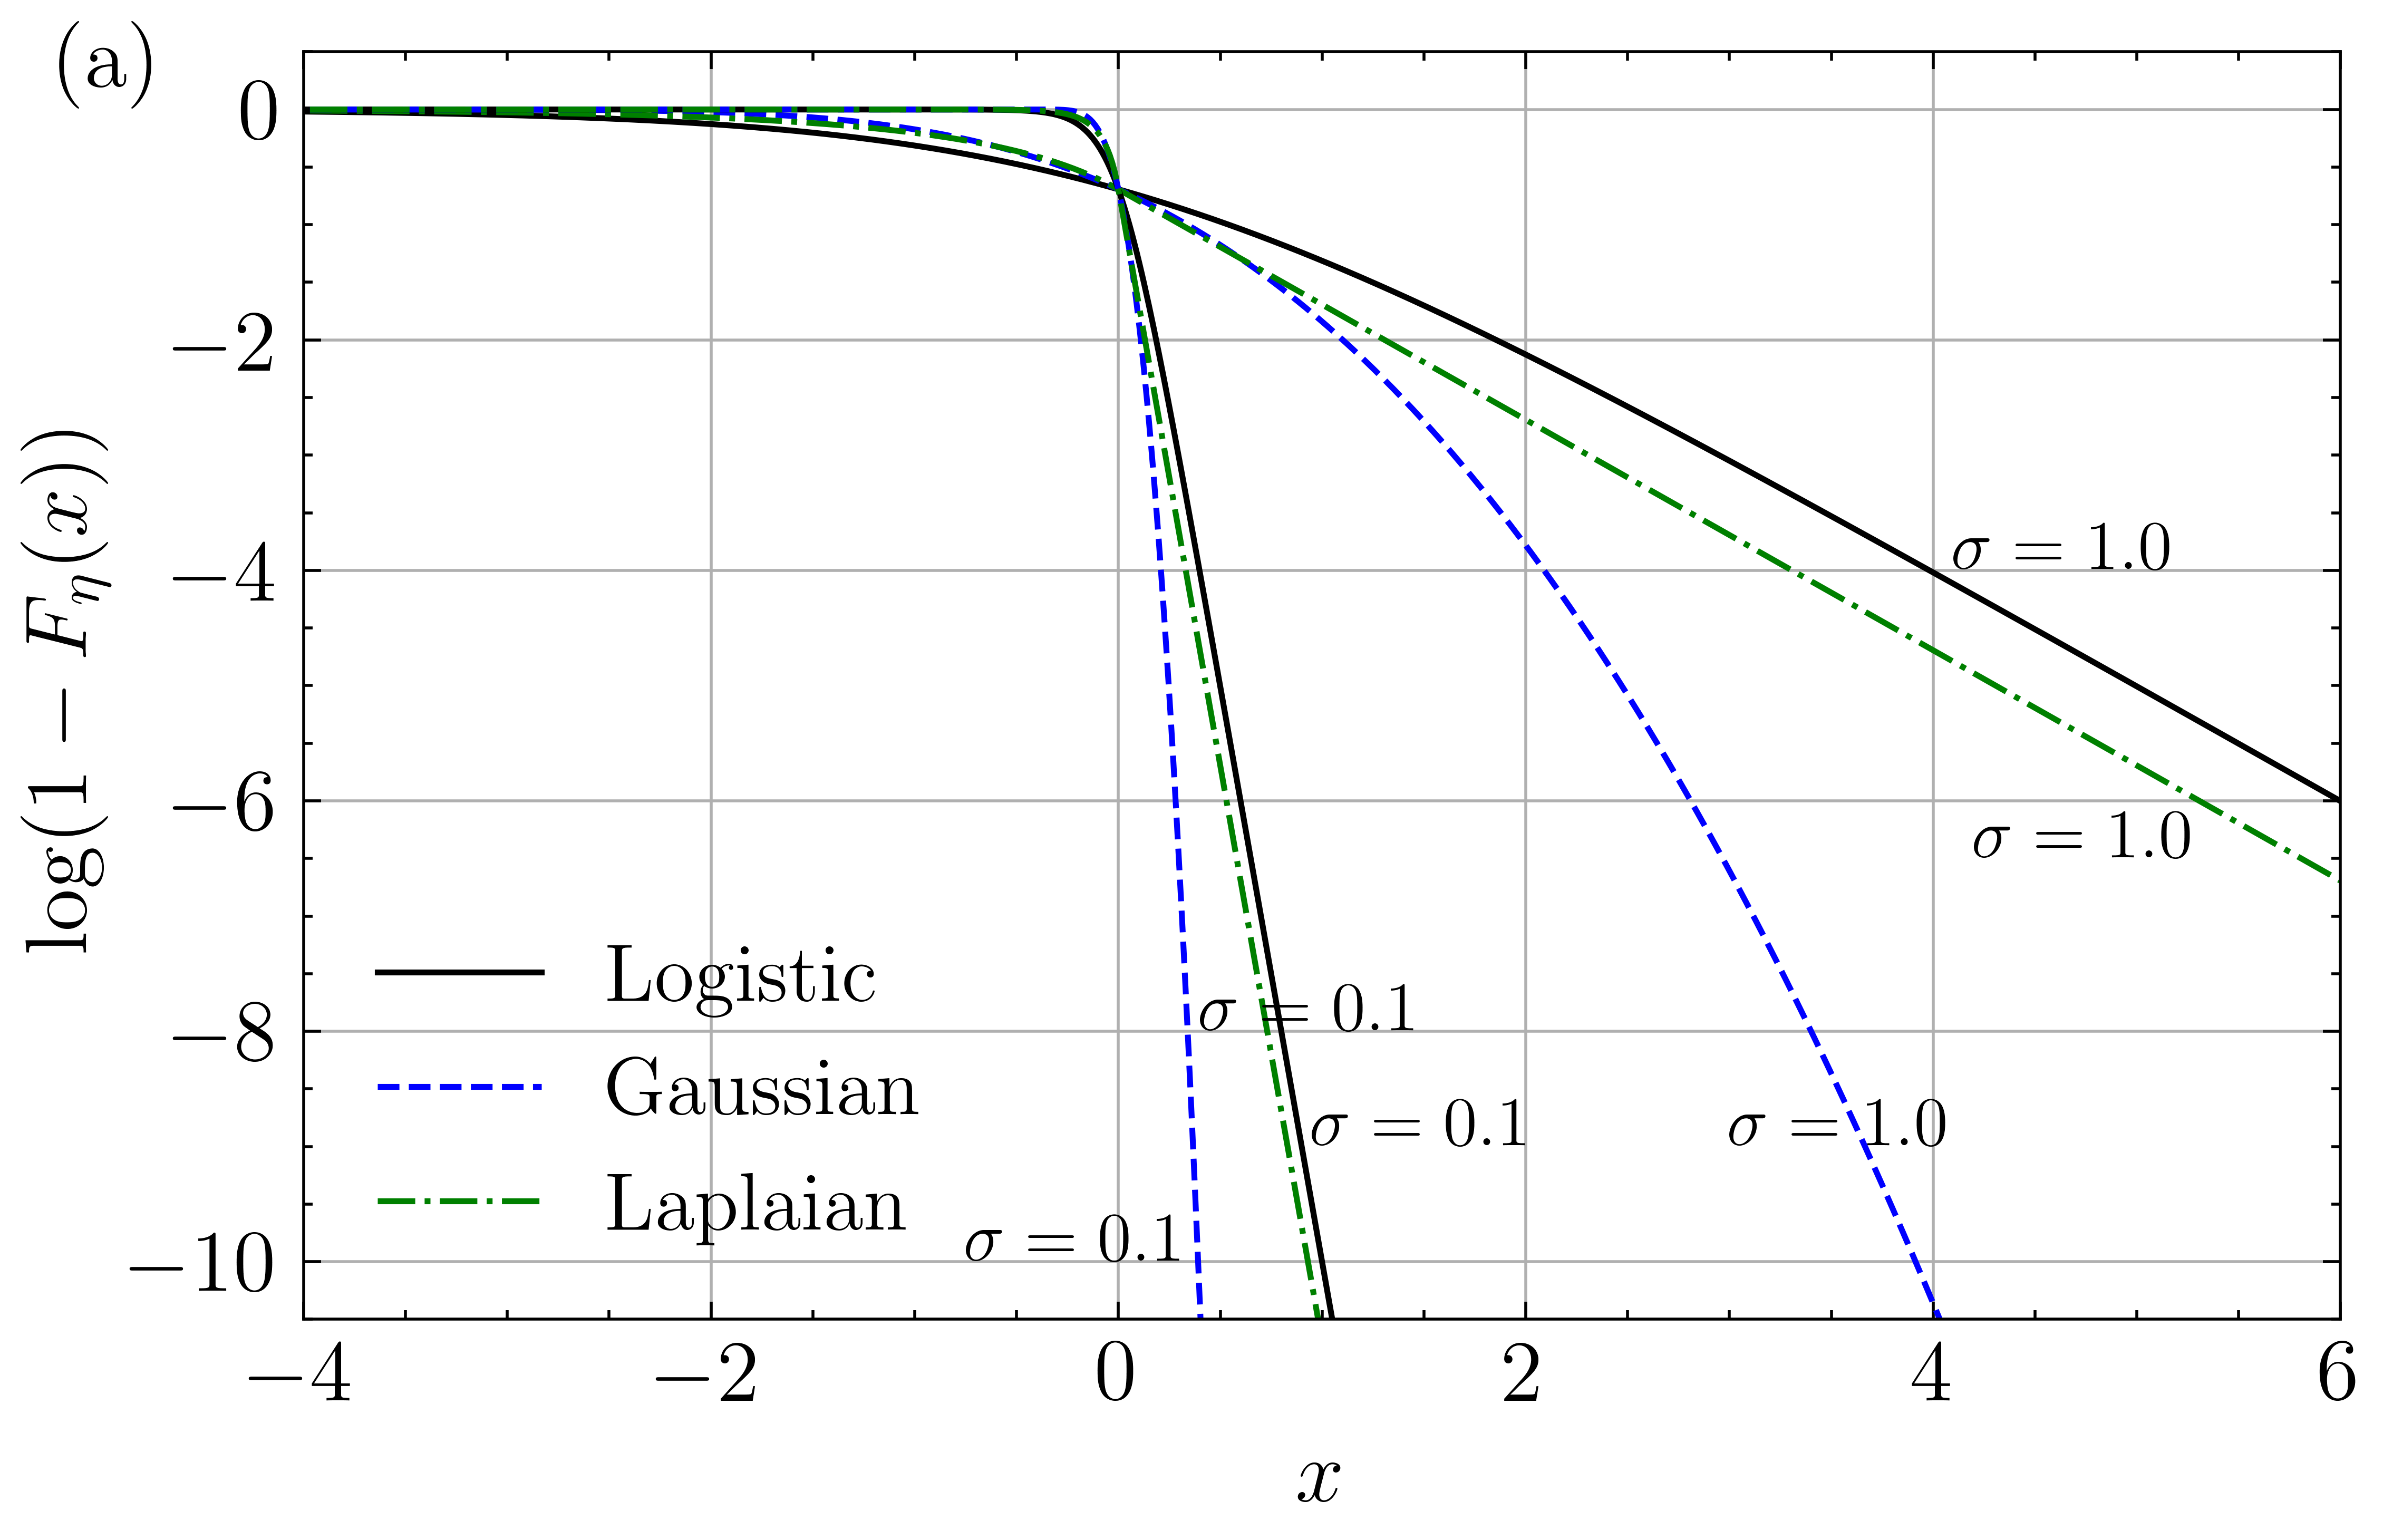

In [42]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import scienceplots
from matplotlib.lines import Line2D

# 设置样式与字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 使用 float64 以提高精度
dtype = torch.float64
u = torch.linspace(-6, 6, 1000, dtype=dtype)

# 定义各 CDF 的 log(1 - F)
def log1m_logistic_cdf(u, sigma):
    return torch.log1p(-1 / (1 + torch.exp(-u / sigma)))

def log1m_gaussian_cdf(u, sigma):
    cdf = 0.5 + 0.5 * torch.erf(u / (math.sqrt(2) * sigma))
    return torch.log(torch.clamp(1.0 - cdf, min=1e-12))

def log1m_laplace_cdf(u, sigma):
    cdf = torch.where(
        u < 0,
        0.5 * torch.exp(u / sigma),
        1 - 0.5 * torch.exp(-u / sigma)
    )
    return torch.log(torch.clamp(1.0 - cdf, min=1e-12))

# 仅使用 sigma = 1.0 和 0.1
sigmas = [1.0, 0.1]
colors = ['black', 'blue', 'red']

fig, ax = plt.subplots(figsize=(6.0, 4.0))

for sigma, color in zip(sigmas, colors):
    y_logistic = log1m_logistic_cdf(u, sigma)
    y_gaussian = log1m_gaussian_cdf(u, sigma)
    y_laplace = log1m_laplace_cdf(u, sigma)

    # Logistic（虚线）
    ax.plot(u, y_logistic, linestyle='-', color='black', label=f'Logistic, σ={sigma}')
    # Gaussian（实线）
    ax.plot(u, y_gaussian, linestyle='--', color='blue', label=f'Gaussian, σ={sigma}')
    # Laplace（点划线）
    ax.plot(u, y_laplace, linestyle='-.', color='green', label=f'Laplace, σ={sigma}')

# 手动标注 sigma
ax.text(4.1, -4, r'$\sigma=1.0$', fontsize=12)
ax.text(0.95, -9, r'$\sigma=0.1$', fontsize=12)
ax.text(3.0, -9, r'$\sigma=1.0$', fontsize=12)
ax.text(-0.75, -10, r'$\sigma=0.1$', fontsize=12)
ax.text(0.4, -8, r'$\sigma=0.1$', fontsize=12)
ax.text(4.2, -6.5, r'$\sigma=1.0$', fontsize=12)

# 坐标轴标签
ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$\log(1 - F_\eta(x))$', fontsize=15, labelpad=3)

# 范围设置
ax.set_xlim(-4, 6)
ax.set_ylim(-10.5, 0.5)
ax.grid(True)

# 图例（按类型分组）
custom_lines = [
    Line2D([0], [0], color='black', linestyle='-', lw=1),
    Line2D([0], [0], color='blue', linestyle='--', lw=1),
    Line2D([0], [0], color='green', linestyle='-.', lw=1)
]
ax.legend(custom_lines, ['Logistic', 'Gaussian', 'Laplaian'], loc='lower left', fontsize=14)

# 子图标注
ax.text(-5.2, 0.2, '(a)', fontsize=15)

# 输出 & 保存
fig.tight_layout()
fig.savefig('D:/PRE2023 2025/Fig2a.eps', dpi=800, format='eps')  # 修改为你的目标路径
plt.show()


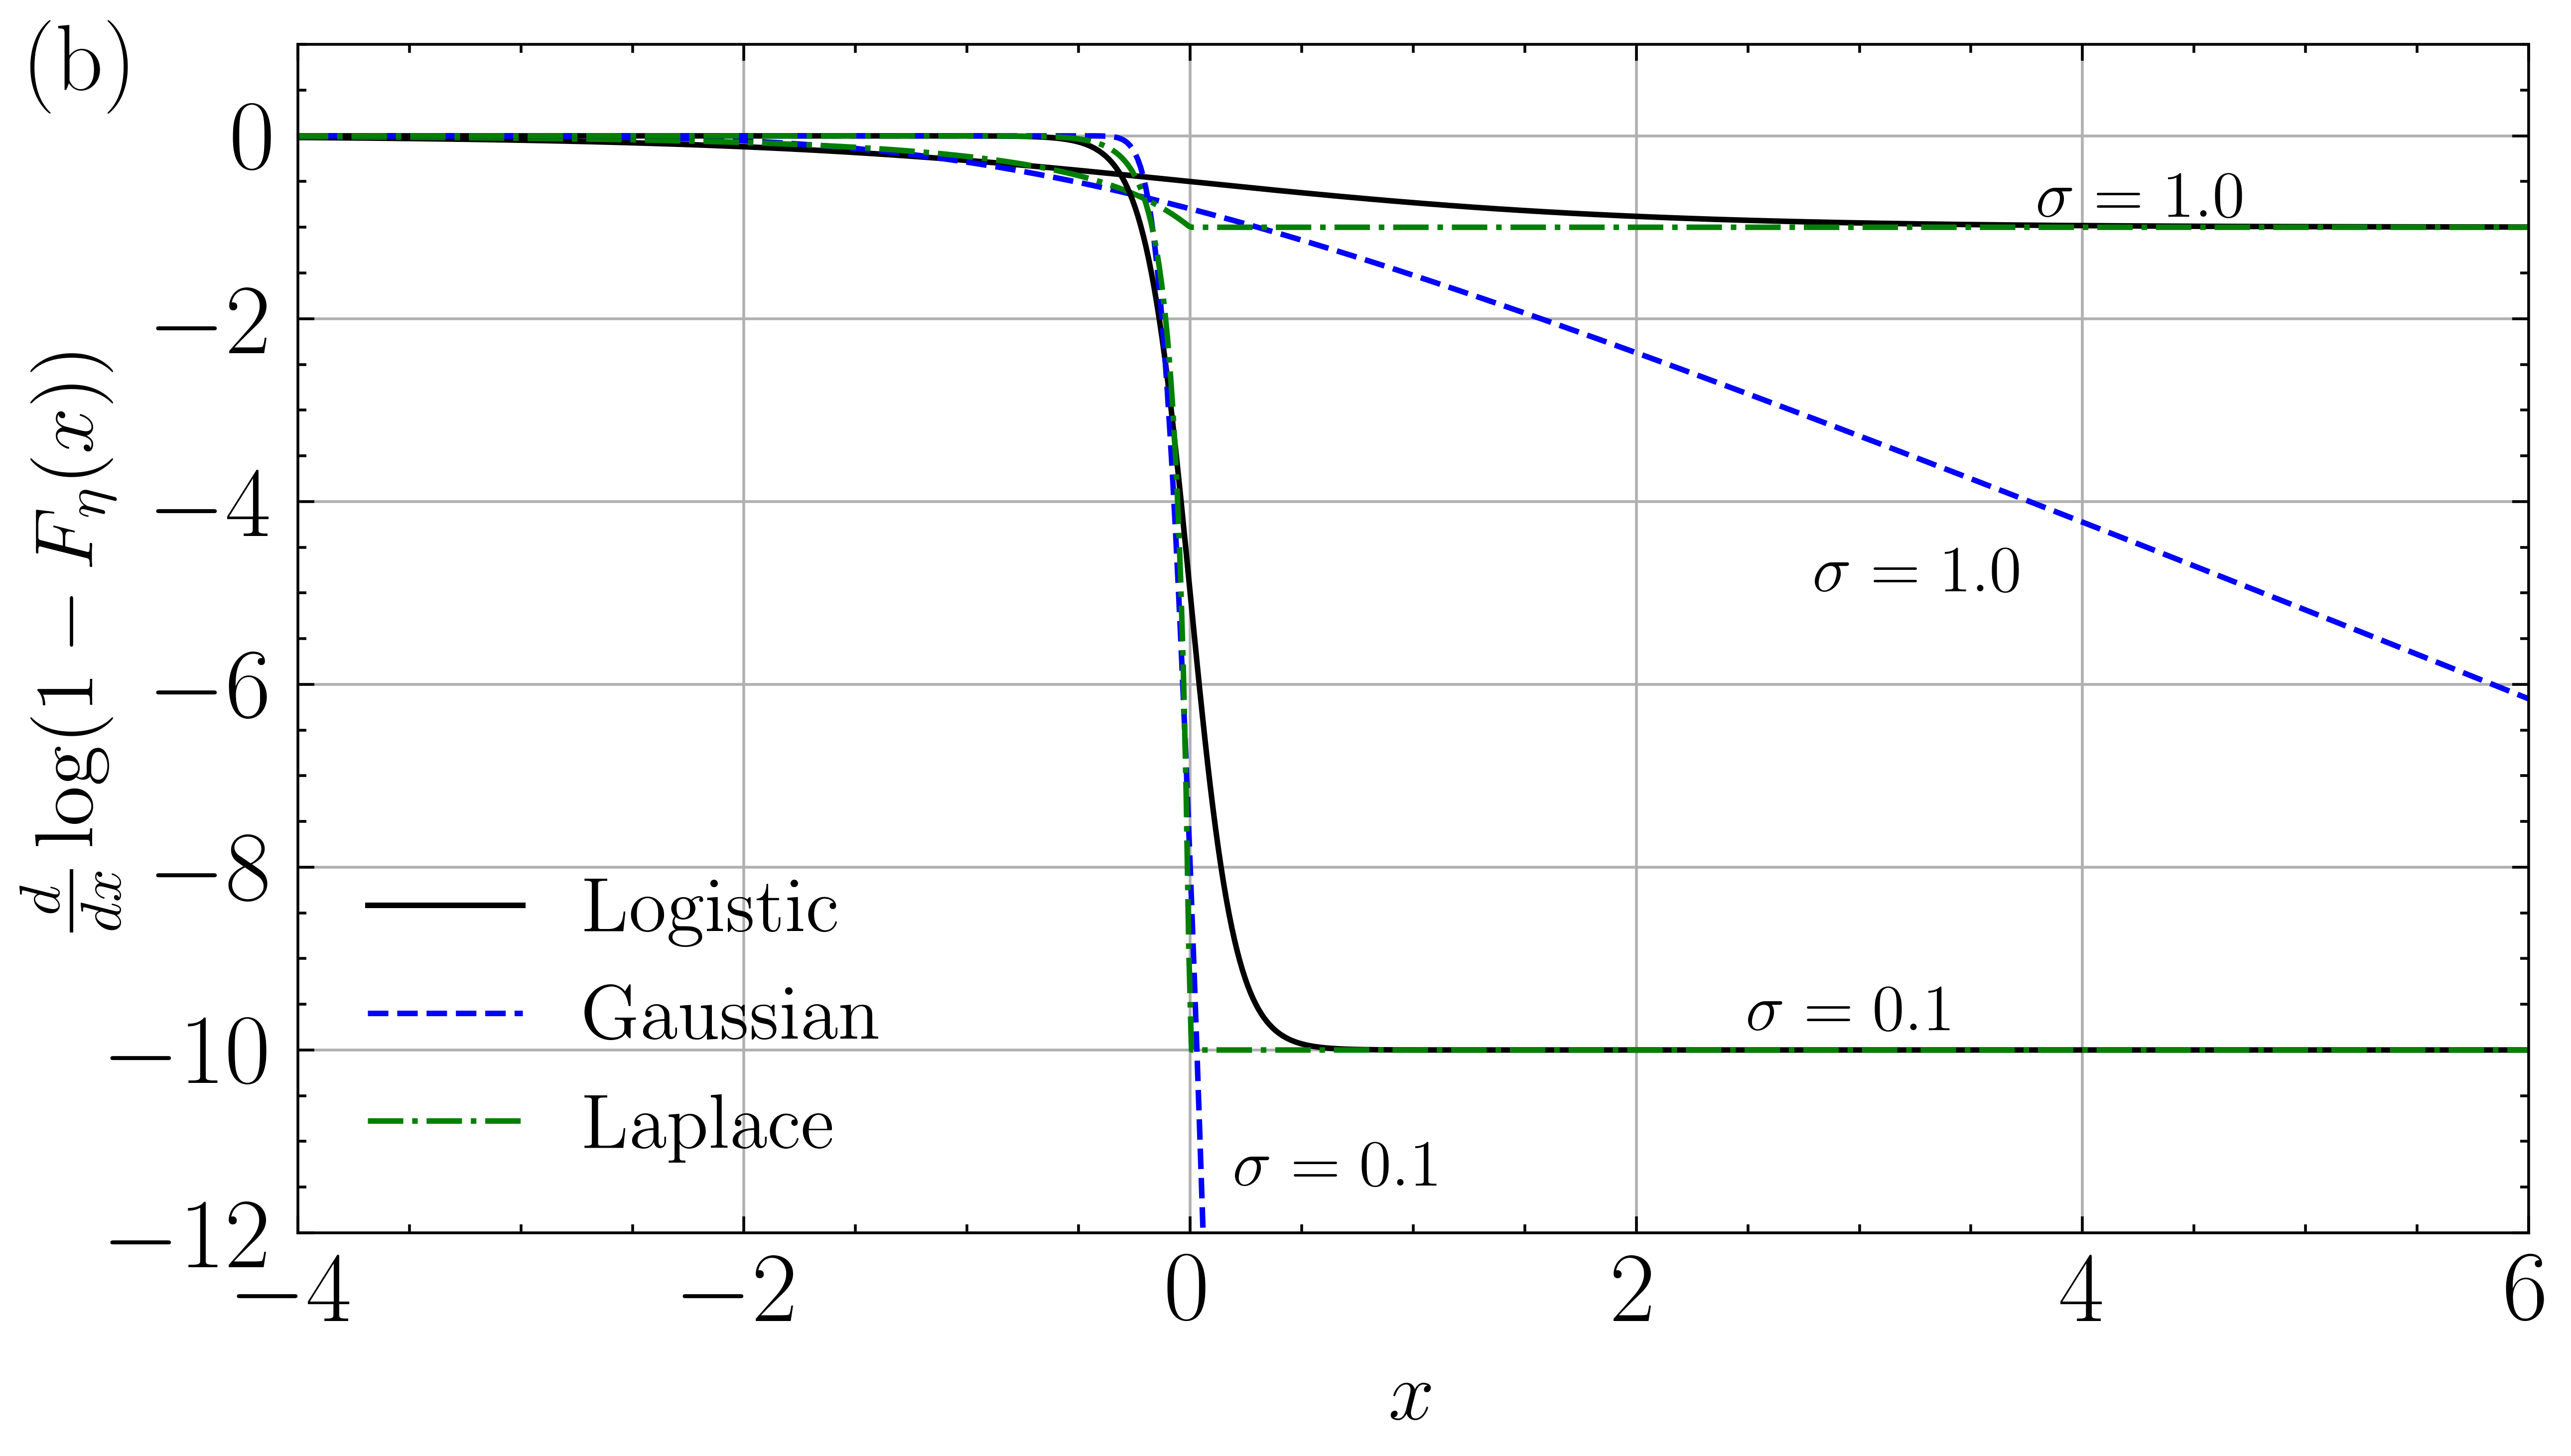

In [43]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from matplotlib.lines import Line2D

# 设置样式
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams.update({
    'font.size': 15,
    'figure.dpi': 800,
    'axes.unicode_minus': False
})

# 定义横轴 x
u = torch.linspace(-6, 6, 1000, dtype=torch.float64)
u.requires_grad_(True)

# 仅使用 sigma = 1.0 和 0.1
sigmas = [1.0, 0.1]

# Logistic: log(1 - sigmoid(u/sigma))
def log_one_minus_logistic_cdf(u, sigma):
    return -torch.nn.functional.softplus(u / sigma)

# Gaussian: log(1 - Φ(u/sigma)) = log_ndtr(-u/sigma)
def log_one_minus_gaussian_cdf(u, sigma):
    return torch.special.log_ndtr(-u / sigma)

# Laplace: 数值稳定版本
def log_one_minus_laplace_cdf(u, sigma):
    """
    计算 log(1 - F_Laplace(u)) 的数值稳定版本
    """
    scaled_u = u / sigma
    
    # 对于 u < 0: log(1 - 0.5 * exp(u/sigma))
    # 使用 log1p(-0.5 * exp(u/sigma)) 提高数值稳定性
    neg_mask = u < 0
    
    # 对于 u >= 0: log(0.5 * exp(-u/sigma)) = log(0.5) - u/sigma
    pos_mask = u >= 0
    
    result = torch.zeros_like(u)
    
    # 处理负数部分：使用 log1p 避免 1-x 的精度损失
    if neg_mask.any():
        exp_term = torch.exp(scaled_u[neg_mask])
        result[neg_mask] = torch.log1p(-0.5 * exp_term)
    
    # 处理非负数部分
    if pos_mask.any():
        result[pos_mask] = torch.log(torch.tensor(0.5)) - scaled_u[pos_mask]
    
    return result

# 数值稳定的Laplace梯度计算
def grad_log_one_minus_laplace_cdf(u, sigma):
    """
    计算 d/du log(1 - F_Laplace(u)) 的数值稳定版本
    """
    scaled_u = u / sigma
    neg_mask = u < 0
    pos_mask = u >= 0
    
    result = torch.zeros_like(u)
    
    # 对于 u < 0: -0.5 * exp(u/sigma) / sigma / (1 - 0.5 * exp(u/sigma))
    # 使用数学变换避免分母接近0的问题
    if neg_mask.any():
        exp_term = torch.exp(scaled_u[neg_mask])
        # 重写为: -exp(u/sigma) / (2*sigma - sigma*exp(u/sigma))
        # 进一步化简为: -exp(u/sigma) / (sigma * (2 - exp(u/sigma)))
        
        # 当 exp(u/sigma) 接近 2 时会有问题，但对于 u < 0，exp(u/sigma) < 1
        # 所以这种情况不会发生
        denominator = 2.0 - exp_term
        result[neg_mask] = -exp_term / (sigma * denominator)
    
    # 对于 u >= 0: -1/sigma
    if pos_mask.any():
        result[pos_mask] = -1.0 / sigma
    
    return result

# 创建图
fig_b, ax_b = plt.subplots(figsize=(6.0, 4.0))

# 自定义图例线条
custom_lines = [
    Line2D([0], [0], color='black', linestyle='-'),
    Line2D([0], [0], color='blue', linestyle='--'),
    Line2D([0], [0], color='green', linestyle='-.')
]

for sigma in sigmas:
    # Logistic 梯度
    u_logistic = u.clone().detach().requires_grad_(True)
    log_logistic = log_one_minus_logistic_cdf(u_logistic, sigma)
    grad_log_logistic = torch.autograd.grad(log_logistic.sum(), u_logistic)[0]
    ax_b.plot(u_logistic.detach(), grad_log_logistic.detach(),
              linestyle='-', color='black',
              label=f'Logistic σ={sigma}' if sigma == sigmas[0] else "")
    
    # Gaussian 梯度
    u_gaussian = u.clone().detach().requires_grad_(True)
    log_gaussian = log_one_minus_gaussian_cdf(u_gaussian, sigma)
    grad_log_gaussian = torch.autograd.grad(log_gaussian.sum(), u_gaussian)[0]
    ax_b.plot(u_gaussian.detach(), grad_log_gaussian.detach(),
              linestyle='--', color='blue',
              label=f'Gaussian σ={sigma}' if sigma == sigmas[0] else "")
    
    # Laplace 梯度（数值稳定版本）
    u_laplace = u.clone().detach()
    grad_log_laplace = grad_log_one_minus_laplace_cdf(u_laplace, sigma)
    ax_b.plot(u_laplace, grad_log_laplace,
              linestyle='-.', color='green',
              label=f'Laplace σ={sigma}' if sigma == sigmas[0] else "")

# 设置坐标轴和标签
ax_b.set_xlabel(r'$x$', fontsize=15)
ax_b.set_ylabel(r'$\frac{d}{dx} \log(1 - F_\eta(x))$', fontsize=15, labelpad=-2)
ax_b.set_xlim(-4, 6)
ax_b.set_ylim(-12, 1)
ax_b.grid(True)

# 添加文字标注
ax_b.text(3.8, -0.9, r'$\sigma=1.0$', fontsize=12)
ax_b.text(2.8, -5, r'$\sigma=1.0$', fontsize=12)
ax_b.text(2.5, -9.8, r'$\sigma=0.1$', fontsize=12)
ax_b.text(0.2, -11.5, r'$\sigma=0.1$', fontsize=12)
# 添加图例
ax_b.legend(custom_lines, ['Logistic', 'Gaussian', 'Laplace'], loc='lower left', fontsize=14)
ax_b.text(-5.2, 0.5, '(b)', fontsize=17)
ax_b.tick_params(axis='both', which='major', labelsize=18)
ax_b.set_yticks(range(-12, 1, 2))
# 保存图像
fig_b.tight_layout()
fig_b.subplots_adjust(left=0.02)
fig_b.savefig('D:/PRE2023 2025/Fig2b.eps', dpi=800, format='eps')
plt.show()
